# Read the actions off a video — the inverse-dynamics interpreter

**Lecture 14 · Video World Models** — *Build a World Model from Scratch* (Vizuara)

Video world models such as **UniPi** split robot control into two stages:

1. **The dreamer** — a big text-to-video model, pre-trained on internet video with *no actions*, imagines how the
   task should look: `text + current frame → future frames`.
2. **The interpreter** — a small **inverse-dynamics model (IDM)** looks at two frames and answers: *what did the
   robot have to do to get from this frame to that one?* `f(oₜ, oₜ₊ₖ) → aₜ`

The dreamer is where the internet-scale knowledge lives. The interpreter is the part you can train yourself in
minutes — and it is plain **supervised learning** on any LeRobot dataset, because every recorded episode already
contains `(oₜ, aₜ, oₜ₊ₖ)` triples.

In this notebook we build the interpreter for a real **SO-101** arm, then play the role of the dreamer with
*held-out real video* and check how well the robot's joint commands can be read back off the frames. Finally we
damage the "imagined" frames the way a video generator would, and watch the interpreter break — which is exactly
why the lecture calls inverse dynamics *the brittle part*.

Runs on a free Colab T4 in about 15 minutes.

In [1]:
!pip install -q lerobot


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import math, random, time
import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device, torch.cuda.get_device_name(0) if device.type == 'cuda' else '')

device: cuda Tesla T4


## 1. The data: 50 real SO-101 pick-and-place episodes

`lerobot/svla_so101_pickplace` was recorded by teleoperating an SO-101 arm at 30 fps. Each frame has two camera
views, the arm's joint positions (`observation.state`, 6 numbers) and the commanded joint targets (`action`,
6 numbers: shoulder pan, shoulder lift, elbow flex, wrist flex, wrist roll, gripper).

We keep one camera (`observation.images.up`), resized to 128×128, and hold out 5 whole episodes for testing —
the interpreter never sees them during training.

In [3]:
from lerobot.datasets.lerobot_dataset import LeRobotDataset

ds = LeRobotDataset("lerobot/svla_so101_pickplace")
CAM = "observation.images.up"
print(f"{ds.num_episodes} episodes, {ds.num_frames} frames at {ds.fps} fps, cameras: {ds.meta.camera_keys}")

IMG = 128
loader = torch.utils.data.DataLoader(ds, batch_size=64, num_workers=2, shuffle=False)
frames, actions, states, ep_ids = [], [], [], []
for b in tqdm(loader, desc="decoding video"):
    x = F.interpolate(b[CAM].float(), size=(IMG, IMG), mode="bilinear", antialias=True)
    frames.append((x.clamp(0, 1) * 255).byte())
    actions.append(b["action"].float()); states.append(b["observation.state"].float())
    ep_ids.append(b["episode_index"])
frames = torch.cat(frames)            # (N, 3, 128, 128) uint8
actions = torch.cat(actions)          # (N, 6)
states = torch.cat(states)            # (N, 6)
ep_ids = torch.cat(ep_ids)
print(frames.shape, actions.shape)
JOINTS = ["shoulder_pan", "shoulder_lift", "elbow_flex", "wrist_flex", "wrist_roll", "gripper"]
print("action range per joint:", [f"{j}: {actions[:, i].min():.0f}..{actions[:, i].max():.0f}" for i, j in enumerate(JOINTS)])

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

meta/episodes/chunk-000/file-000.parquet:   0%|          | 0.00/72.6k [00:00<?, ?B/s]

info.json: 0.00B [00:00, ?B/s]

meta/tasks.parquet:   0%|          | 0.00/2.25k [00:00<?, ?B/s]

stats.json: 0.00B [00:00, ?B/s]

...

.gitattributes: 0.00B [00:00, ?B/s]

README.md: 0.00B [00:00, ?B/s]

50 episodes, 11939 frames at 30 fps, cameras: ['observation.images.up', 'observation.images.side']


decoding video:   0%|          | 0/187 [00:00<?, ?it/s]

torch.Size([11939, 3, 128, 128]) torch.Size([11939, 6])
action range per joint: ['shoulder_pan: -93..88', 'shoulder_lift: -100..8', 'elbow_flex: 13..100', 'wrist_flex: 34..99', 'wrist_roll: -93..-20', 'gripper: 0..33']


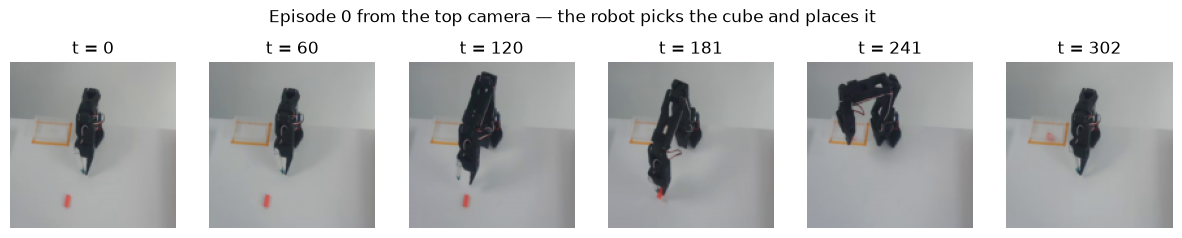

In [4]:
fig, axes = plt.subplots(1, 6, figsize=(15, 2.8))
idx = torch.where(ep_ids == 0)[0]
for ax, k in zip(axes, np.linspace(0, len(idx) - 1, 6).astype(int)):
    ax.imshow(frames[idx[k]].permute(1, 2, 0)); ax.set_title(f"t = {k}"); ax.axis("off")
fig.suptitle("Episode 0 from the top camera — the robot picks the cube and places it"); plt.show()

## 2. Build `(oₜ, oₜ₊ₖ) → aₜ` training pairs

We pair every frame with the frame **k = 5 steps later** (≈ 0.17 s) and ask the network for the action that was
commanded at time *t*. Pairs never cross an episode boundary. Actions are z-scored per joint so all six joints
count equally in the loss.

In [5]:
K = 5
test_eps = [45, 46, 47, 48, 49]
starts = []
for e in ep_ids.unique().tolist():
    idx = torch.where(ep_ids == e)[0]
    starts += [(int(i), e) for i in idx[:-K]]
train_idx = torch.tensor([i for i, e in starts if e not in test_eps])
test_idx = torch.tensor([i for i, e in starts if e in test_eps])
a_mean, a_std = actions[train_idx].mean(0), actions[train_idx].std(0)
norm_a = (actions - a_mean) / a_std
print(f"train pairs: {len(train_idx)}, test pairs: {len(test_idx)} (from {len(test_eps)} unseen episodes)")

train pairs: 10359, test pairs: 1330 (from 5 unseen episodes)


## 3. The interpreter: a ResNet-18 that looks at two frames

Both frames are stacked on the channel axis (6 channels). We start from ImageNet weights — the first convolution
is widened from 3 to 6 input channels by copying its filters — and replace the classifier with a 6-number head.
That's the whole model: ~11M parameters, deliberately small, because the capacity is supposed to live in the dreamer.

In [6]:
def make_idm():
    net = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
    w = net.conv1.weight.data
    net.conv1 = nn.Conv2d(6, 64, 7, 2, 3, bias=False)
    net.conv1.weight.data = torch.cat([w, w], 1) / 2
    net.fc = nn.Linear(512, 6)
    return net

MEAN = torch.tensor([0.485, 0.456, 0.406] * 2).view(1, 6, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225] * 2).view(1, 6, 1, 1)

def batch_inputs(idx, future=None):
    o_t = frames[idx]
    o_k = frames[idx + K] if future is None else future
    x = torch.cat([o_t, o_k], 1).float() / 255
    return ((x - MEAN) / STD)

idm = make_idm().to(device)
print(f"IDM parameters: {sum(p.numel() for p in idm.parameters())/1e6:.1f}M")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


  0%|          | 0.00/44.7M [00:00<?, ?B/s]

 15%|█▌        | 6.75M/44.7M [00:00<00:00, 70.2MB/s]

 34%|███▍      | 15.1M/44.7M [00:00<00:00, 80.0MB/s]

 53%|█████▎    | 23.8M/44.7M [00:00<00:00, 84.5MB/s]

 74%|███████▍  | 33.1M/44.7M [00:00<00:00, 89.5MB/s]

 95%|█████████▌| 42.6M/44.7M [00:00<00:00, 93.1MB/s]

100%|██████████| 44.7M/44.7M [00:00<00:00, 89.1MB/s]

IDM parameters: 11.2M


In [7]:
EPOCHS, BS = 6, 128
opt = torch.optim.AdamW(idm.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-4, total_steps=EPOCHS * math.ceil(len(train_idx) / BS))
history = []
for ep in range(EPOCHS):
    idm.train(); perm = train_idx[torch.randperm(len(train_idx))]; tot = 0
    for i in tqdm(range(0, len(perm), BS), desc=f"epoch {ep+1}/{EPOCHS}", leave=False):
        b = perm[i:i + BS]
        x = batch_inputs(b)
        # light augmentation: the same random shift on both frames
        dx, dy = np.random.randint(-6, 7, 2)
        x = torch.roll(x, shifts=(int(dy), int(dx)), dims=(2, 3))
        pred = idm(x.to(device))
        loss = F.smooth_l1_loss(pred, norm_a[b].to(device))
        opt.zero_grad(); loss.backward(); opt.step(); sched.step()
        tot += loss.item() * len(b)
    history.append(tot / len(train_idx))
    print(f"epoch {ep+1}: train loss {history[-1]:.4f}")

epoch 1/6:   0%|          | 0/81 [00:00<?, ?it/s]

epoch 1: train loss 0.2239


epoch 2/6:   0%|          | 0/81 [00:00<?, ?it/s]

epoch 2: train loss 0.0350


epoch 3/6:   0%|          | 0/81 [00:00<?, ?it/s]

...

epoch 4: train loss 0.0125


epoch 5/6:   0%|          | 0/81 [00:00<?, ?it/s]

epoch 5: train loss 0.0096


epoch 6/6:   0%|          | 0/81 [00:00<?, ?it/s]

epoch 6: train loss 0.0088


## 4. Read the actions off unseen video

Now play the dreamer: give the interpreter the current frame and the *real* frame 5 steps later from the 5
held-out episodes, and compare the joint commands it reads off the video with the ones the human operator sent.

Two reference points:

- **"predict the average action"** — what you get with no information at all,
- **"copy the current joint state"** — a strong baseline that *cheats* by reading the robot's joint sensors
  (the IDM only ever sees pixels).

In [8]:
@torch.no_grad()
def predict(idx, future=None):
    idm.eval(); out = []
    for i in range(0, len(idx), 256):
        b = idx[i:i + 256]
        fut = None if future is None else future[i:i + 256]
        out.append(idm(batch_inputs(b, fut).to(device)).cpu())
    return torch.cat(out) * a_std + a_mean

pred = predict(test_idx)
true = actions[test_idx]
mae_idm = (pred - true).abs().mean(0)
mae_mean = (a_mean - true).abs().mean(0)
mae_state = (states[test_idx] - true).abs().mean(0)
print(f"{'joint':<14}{'IDM (pixels)':>14}{'avg action':>12}{'copy state*':>13}")
for j, n in enumerate(JOINTS):
    print(f"{n:<14}{mae_idm[j]:>14.2f}{mae_mean[j]:>12.2f}{mae_state[j]:>13.2f}")
print(f"{'MEAN':<14}{mae_idm.mean():>14.2f}{mae_mean.mean():>12.2f}{mae_state.mean():>13.2f}")
print("(mean absolute error in the dataset's joint units; * uses the robot's own joint sensors)")

joint           IDM (pixels)  avg action  copy state*
shoulder_pan            2.07       46.75         5.17
shoulder_lift           2.24       31.84         3.27
elbow_flex              2.51       24.66         3.55
wrist_flex              2.44        8.71         1.95
wrist_roll              3.58       18.44         2.27
gripper                 1.28        7.37         2.32
MEAN                    2.35       22.96         3.09
(mean absolute error in the dataset's joint units; * uses the robot's own joint sensors)


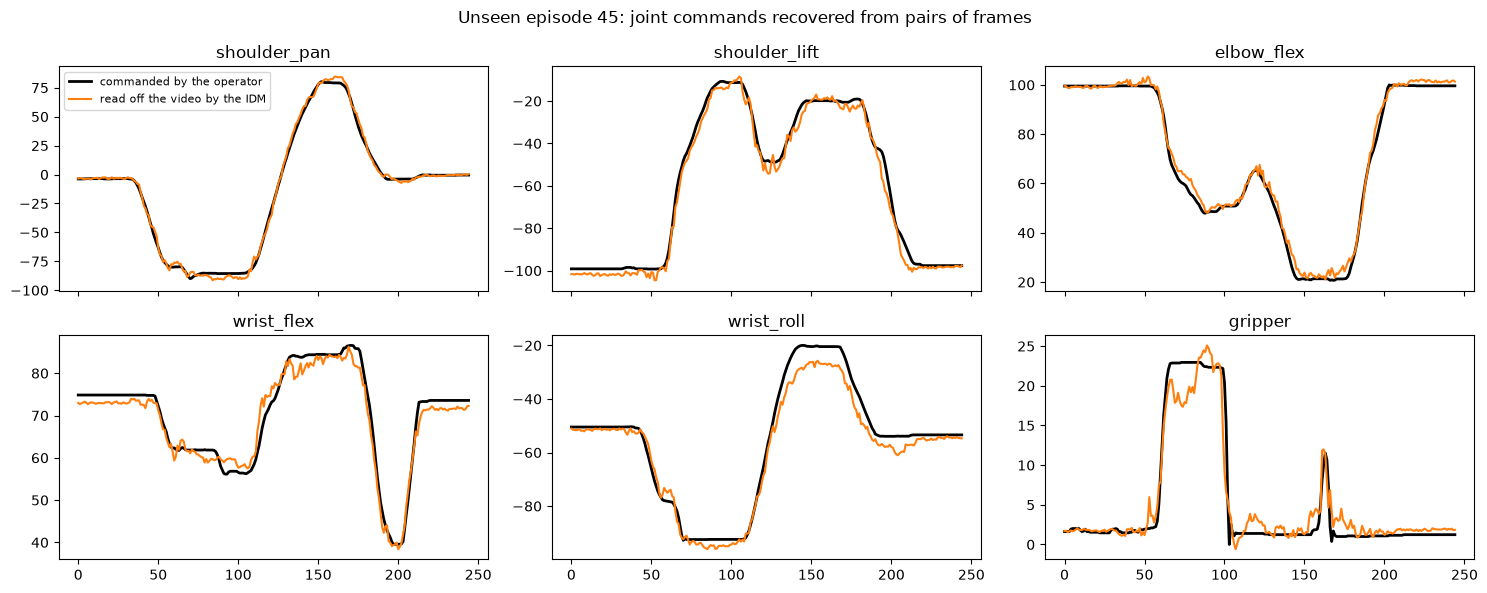

In [9]:
e = test_eps[0]
sel = torch.tensor([k for k, i in enumerate(test_idx.tolist()) if ep_ids[i] == e])
fig, axes = plt.subplots(2, 3, figsize=(15, 6), sharex=True)
for j, ax in enumerate(axes.flat):
    ax.plot(true[sel, j], color="black", lw=2, label="commanded by the operator")
    ax.plot(pred[sel, j], color="tab:orange", lw=1.5, label="read off the video by the IDM")
    ax.set_title(JOINTS[j])
axes[0, 0].legend(fontsize=8)
fig.suptitle(f"Unseen episode {e}: joint commands recovered from pairs of frames"); plt.tight_layout(); plt.show()

## 5. The brittle part: what if the "imagined" future is imperfect?

A real video model doesn't hand the interpreter a perfect future frame — it generates one, with blur, texture
noise and objects that drift. Let's simulate three kinds of imperfection on the *future* frame only and measure how
much the recovered actions degrade.

blur ['1: 2.65', '2: 3.10', '4: 3.83']


noise ['10: 6.22', '25: 16.54', '50: 22.51']


drift ['4: 4.71', '8: 7.13', '16: 9.86']


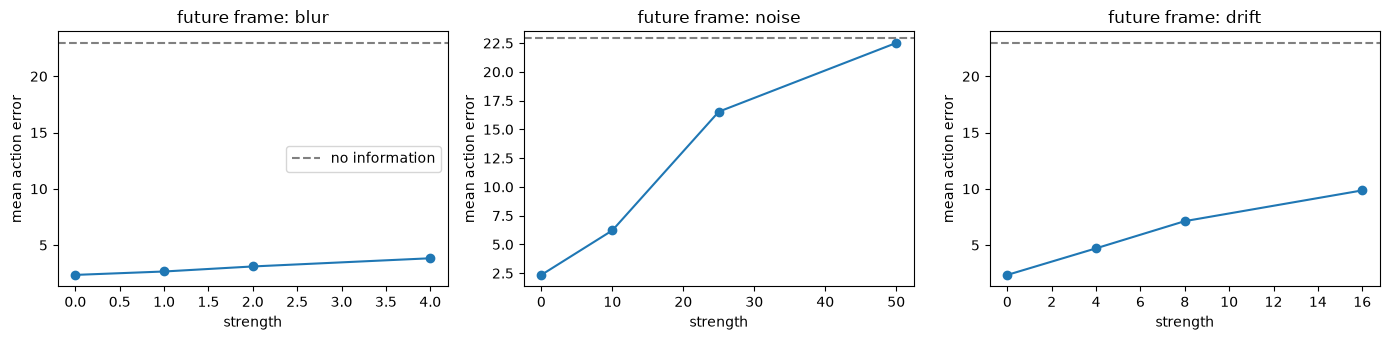

In [10]:
def degrade(kind, strength):
    fut = frames[test_idx + K].float()
    if kind == "blur":
        k = int(2 * strength + 1)
        fut = torchvision.transforms.functional.gaussian_blur(fut, kernel_size=k, sigma=strength)
    elif kind == "noise":
        fut = fut + torch.randn_like(fut) * strength
    elif kind == "drift":       # the generator puts the arm a bit off: shift the frame
        fut = torch.roll(fut, shifts=(0, int(strength)), dims=(2, 3))
    return fut.clamp(0, 255).byte()

results = {}
for kind, levels in [("blur", [1, 2, 4]), ("noise", [10, 25, 50]), ("drift", [4, 8, 16])]:
    results[kind] = [(lv, (predict(test_idx, degrade(kind, lv)) - true).abs().mean().item()) for lv in levels]
    print(kind, [f"{lv}: {m:.2f}" for lv, m in results[kind]])

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
for ax, (kind, rs) in zip(axes, results.items()):
    ax.plot([0] + [lv for lv, _ in rs], [mae_idm.mean().item()] + [m for _, m in rs], "o-")
    ax.axhline(mae_mean.mean().item(), ls="--", color="gray", label="no information")
    ax.set_title(f"future frame: {kind}"); ax.set_xlabel("strength"); ax.set_ylabel("mean action error")
axes[0].legend(); plt.tight_layout(); plt.show()

## What you just saw

- A small network can read a robot's joint commands off **two video frames** from episodes it has never seen —
  that is the trick that lets video world models use action-free internet video: learn *the future* from the
  internet, learn *the actions* from a little robot data.
- The interpreter is only as good as the frames it is given. Blur, noise and small spatial drift in the
  "imagined" future quickly push its error toward the no-information baseline — the brittleness the lecture warns
  about, and the reason the field moved on to models that predict **video and actions jointly** (DreamZero,
  Lecture 15).

**Try next:** use both cameras (stack 12 channels); predict the whole 5-step action chunk instead of one action;
train with the degradations as augmentation and see how much robustness you can buy back.